In [7]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

engine = create_engine("bigquery://olist-data-pipeline-507001")

In [18]:
query = """
SELECT
    r.customer_key,
    c.customer_unique_id,
    r.customer_segment,
    r.recency AS recency_days,
    r.frequency,
    r.monetary AS monetary_value,
    r.recency_score,
    r.frequency_score,
    r.monetary_score,
    r.rfm_code,
    r.rfm_total_score AS rfm_score
FROM `olist-data-pipeline-507001.olist_mart.fct_customer_rfm` AS r
LEFT JOIN `olist-data-pipeline-507001.olist_mart.dim_customer` AS c
    ON r.customer_key = c.customer_key
ORDER BY r.monetary DESC

"""

rfm_df = pd.read_sql(query, con=engine)

In [19]:
rfm_segment_df = (
    rfm_df
    .groupby("customer_segment", as_index=False)["monetary_value"]
    .sum()
    .rename(columns={"monetary_value": "total_revenue"})
    .sort_values("total_revenue", ascending=True)
)

rfm_segment_df

,customer_segment,total_revenue
0,At Risk,19571.67
2,Champions,24217.57
4,Loyal Customers,34649.55
6,Potential Loyalists,61611.38
7,Recent One-Time Customers,2316157.63
3,Lost Customers,2675209.82
5,Needs Attention,3909336.23
1,Big Spenders,4453646.89


In [20]:
def plot_rfm_segment_summary(rfm_segment_df):
    df = rfm_segment_df

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        df["customer_segment"],
        df["total_revenue"],
    )

    ax.set_title("Revenue by RFM Customer Segment")
    ax.set_xlabel("Total Revenue")
    ax.set_ylabel("Customer Segment")
    ax.grid(axis="x", alpha=0.2)

    return fig



In [22]:
rfm_segment_df

,customer_segment,total_revenue
0,At Risk,19571.67
2,Champions,24217.57
4,Loyal Customers,34649.55
6,Potential Loyalists,61611.38
7,Recent One-Time Customers,2316157.63
3,Lost Customers,2675209.82
5,Needs Attention,3909336.23
1,Big Spenders,4453646.89


In [23]:
rfm_segment_df["total_revenue"].sum()

np.float64(13494400.739999998)

In [24]:
rfm_df["monetary_value"].sum()

np.float64(13494400.74)

In [31]:
rfm_df.head()

,customer_key,customer_unique_id,customer_segment,recency_days,frequency,monetary_value,recency_score,frequency_score,monetary_score,rfm_code,rfm_score
0,4a2cd709fb8df349fb5b9452f366773f,0a0a92112bd4c708ca5fde585afaa872,Needs Attention,384,1,13440.0,2,1,5,215,8
1,a284a6f2773aaef99e7f7826492041c1,da122df9eeddfedc1dc1f5349a1a690c,Lost Customers,565,2,7388.0,1,2,5,125,8
2,498a517061ed6507604de4f7d21f2350,763c8b1c9c68a0229c42c9fc6f662b93,Big Spenders,95,1,7160.0,5,1,5,515,11
3,e066acc3e6a50682a954ee098e0bc62c,dc4802a71eae9be1dd28f5d788ceb526,Lost Customers,613,1,6735.0,1,1,5,115,7
4,3109752b1510e2c7163050af45788d25,459bef486812aa25204be022145caa62,Big Spenders,85,1,6729.0,5,1,5,515,11


In [4]:
top_customers_df = (
    rfm_df[
        ["customer_unique_id", "customer_segment", "monetary_value"]
    ]
    .head(10)
    .sort_values("monetary_value", ascending=True)
)

top_customers_df

,customer_unique_id,customer_segment,monetary_value
9,a229eba70ec1c2abef51f04987deb7a5,Big Spenders,4400.0
8,48e1ac109decbb87765a3eade6854098,Big Spenders,4590.0
7,eebb5dda148d3893cdaf5b5ca3040ccb,Lost Customers,4690.0
6,4007669dec559734d6f53e029e360987,Needs Attention,5934.6
5,ff4159b92c40ebe40454e3e6a7c35ed6,Lost Customers,6499.0
4,459bef486812aa25204be022145caa62,Big Spenders,6729.0
3,dc4802a71eae9be1dd28f5d788ceb526,Lost Customers,6735.0
2,763c8b1c9c68a0229c42c9fc6f662b93,Big Spenders,7160.0
1,da122df9eeddfedc1dc1f5349a1a690c,Lost Customers,7388.0
0,0a0a92112bd4c708ca5fde585afaa872,Needs Attention,13440.0


In [11]:
def plot_rfm_top_customers(rfm_df, top_n=10):
    df = rfm_df.head(top_n)

    labels = (
        df["customer_unique_id"]
        .astype(str)
        .str.slice(0, 12)
    )

    plot_df = pd.DataFrame({
        "customer": labels,
        "monetary_value": df["monetary_value"],
    }).sort_values(
        "monetary_value",
        ascending=True,
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(
        plot_df["customer"],
        plot_df["monetary_value"],
    )

    ax.set_title(
        f"Top {len(plot_df)} Customers by Monetary Value"
    )

    ax.set_xlabel("Monetary Value")
    ax.set_ylabel("Customer")
    ax.grid(axis="x", alpha=0.2)

    return fig

In [14]:
rfm_df

,customer_key,customer_unique_id,customer_segment,recency_days,frequency,monetary_value,recency_score,frequency_score,monetary_score,rfm_code,rfm_score
0,4a2cd709fb8df349fb5b9452f366773f,0a0a92112bd4c708ca5fde585afaa872,Needs Attention,384,1,13440.00,2,1,5,215,8
1,a284a6f2773aaef99e7f7826492041c1,da122df9eeddfedc1dc1f5349a1a690c,Lost Customers,565,2,7388.00,1,2,5,125,8
2,498a517061ed6507604de4f7d21f2350,763c8b1c9c68a0229c42c9fc6f662b93,Big Spenders,95,1,7160.00,5,1,5,515,11
3,e066acc3e6a50682a954ee098e0bc62c,dc4802a71eae9be1dd28f5d788ceb526,Lost Customers,613,1,6735.00,1,1,5,115,7
4,3109752b1510e2c7163050af45788d25,459bef486812aa25204be022145caa62,Big Spenders,85,1,6729.00,5,1,5,515,11
...,...,...,...,...,...,...,...,...,...,...,...
95,5ef8b4e395e987c505270064a6d7ece1,c01158adcf91ee8f143d12388abe5f22,Big Spenders,131,1,2299.99,5,1,5,515,11
96,72a63401cfc1fdf95eb716a07cb60bb6,87070b00f89fa49dd0b01ff4bf075b8c,Big Spenders,184,1,2299.95,4,1,5,415,10
97,7383a439f188e2ef222cd2f793cfd880,c7794313e2cd53472b116a751350f132,Big Spenders,63,1,2299.00,5,1,5,515,11
98,be831b893ba742b4b1d91f0e9fa62c8d,e3e0e9112264452e4700d977ce02a4d1,Big Spenders,233,1,2288.00,3,1,5,315,9


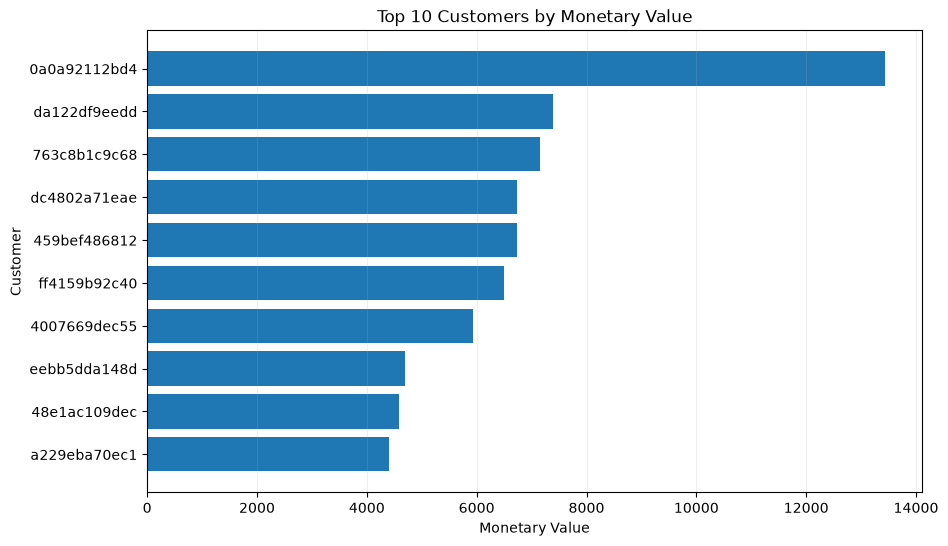

In [16]:
fig = plot_rfm_top_customers(rfm_df)
plt.show()


In [17]:
rfm_segment_df = (
    rfm_df
    .groupby("customer_segment", as_index=False)["monetary_value"]
    .sum()
    .rename(columns={"monetary_value": "total_revenue"})
    .sort_values("total_revenue", ascending=True)
)

rfm_segment_df

,customer_segment,total_revenue
1,Champions,4080.00
3,Needs Attention,54535.56
2,Lost Customers,103891.62
0,Big Spenders,166182.76


In [26]:
rfm_segment_df["total_revenue"].sum()

np.float64(13494400.739999998)

In [27]:
rfm_segment_df["total_revenue"] = rfm_segment_df["total_revenue"].round(2)

In [28]:
top_customers_df["monetary_value"] = top_customers_df["monetary_value"].round(2)

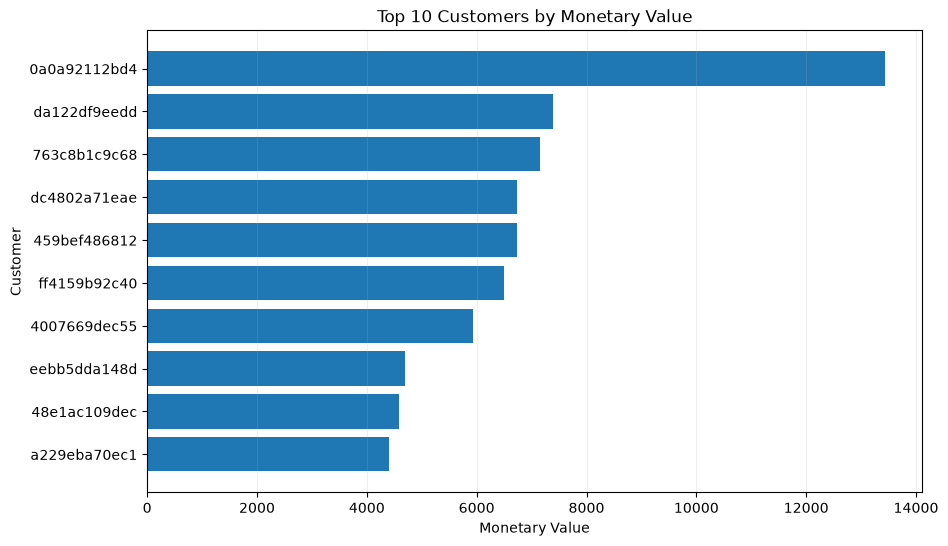

In [29]:
fig = plot_rfm_top_customers(rfm_df)
plt.show()

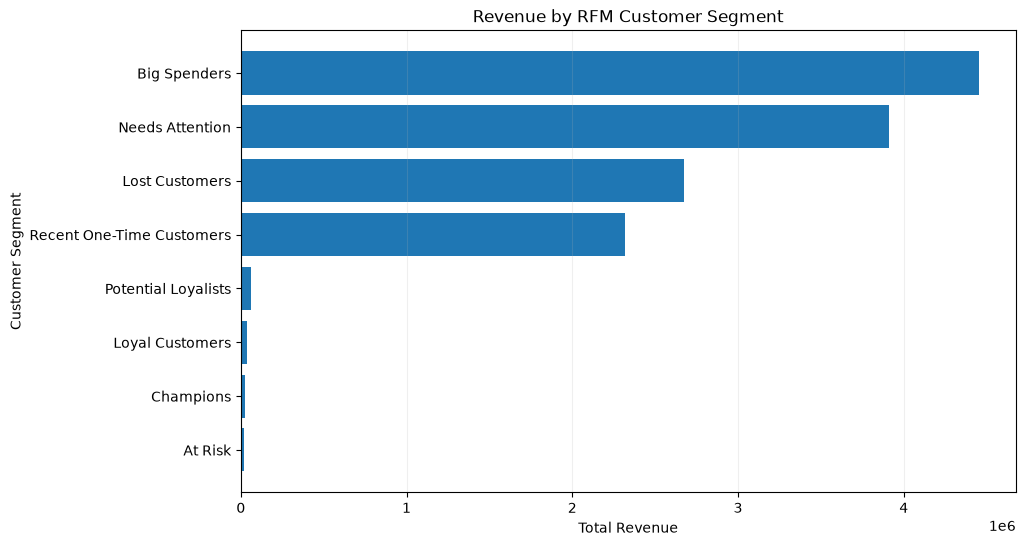

In [30]:
fig = plot_rfm_segment_summary(rfm_segment_df)
plt.show()

In [33]:
rfm_segment_df = rfm_segment_df.reset_index(drop=True)

In [35]:
rfm_segment_df

,customer_segment,total_revenue
0,At Risk,19571.67
1,Champions,24217.57
2,Loyal Customers,34649.55
3,Potential Loyalists,61611.38
4,Recent One-Time Customers,2316157.63
5,Lost Customers,2675209.82
6,Needs Attention,3909336.23
7,Big Spenders,4453646.89
